<a href="https://colab.research.google.com/github/pharno1/pharno1.github.io/blob/main/Analyse_MissionMe_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse des campagnes publicitaires MissionMe

**Période :** août à décembre 2025  
**Outil :** Python / Google Colab  
**Source :** onglet 2 du fichier Excel corrigé

## Questions métier

1. Qu'est-ce qui a attiré le plus les internautes ?
2. Pourquoi sont-ils venus ?
3. Quelles tranches d'âge ciblées ont le mieux réagi ?

> **Précaution importante :** le fichier ne contient pas l'âge réel des personnes ayant cliqué. La variable `Cible MM` décrit le public ciblé par la campagne. Les résultats d'âge doivent donc être formulés comme « campagnes ciblant les 18–35 ans », et non comme « visiteurs âgés de 18–35 ans ».

## 1. Installation et importation des bibliothèques

In [1]:
!pip -q install openpyxl unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.1 MB/s eta 0:00:00


In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## 2. Chargement du fichier dans Google Colab

Exécuter la cellule, puis sélectionner le fichier Excel. Le notebook utilise automatiquement le **deuxième onglet**.

In [3]:
from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
excel = pd.ExcelFile(file_name)
print("Onglets disponibles :", excel.sheet_names)

sheet_name = excel.sheet_names[1]
df_raw = pd.read_excel(file_name, sheet_name=sheet_name)
print(f"Onglet utilisé : {sheet_name}")
print(f"Dimensions : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
display(df_raw.head())

Saving MissionMe-Pub-1-août-2025-14-déc-2025 (1).xlsx to MissionMe-Pub-1-août-2025-14-déc-2025 (1).xlsx
Onglets disponibles : ['MissionMe-Pub-1-août-2025-14-dé', 'MissionMe-Pub-1-août-2025-1 (2)', 'Traitement_v1']
Onglet utilisé : MissionMe-Pub-1-août-2025-1 (2)
Dimensions : 811 lignes × 25 colonnes


,Fin,Nom de la publicité,Format MM,Cible MM,Thème du post,Résultats,Indicateur de résultats,Cout par résultat,Montant dépensé (EUR),Impressions,Nom de l'ensemble de publicités,Paramètre d'attribution,Couverture,Lectures de vidéo de 2 secondes consécutives,Lectures de vidéo de 3 secondes,Lectures de vidéos,Clics (tous),Clics sur un lien,Followers sur Instagram,J'aime sur Facebook,Interactions avec la publication,Partages de publications,actions:group_join,Enregistrements de publication,Interaction avec la Page
0,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,NaN,NaN,NaN,2.0,profile_visit_view,0.405000,0.81,207,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,207,NaN,20.0,197.0,2,2.0,2,NaN,23.0,NaN,NaN,NaN,23.0
1,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,NaN,NaN,NaN,5.0,profile_visit_view,0.340000,1.70,460,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,455,NaN,58.0,443.0,6,6.0,0,NaN,66.0,NaN,NaN,NaN,66.0
2,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,NaN,NaN,NaN,2.0,profile_visit_view,0.570000,1.14,536,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,517,NaN,18.0,491.0,2,2.0,3,NaN,21.0,NaN,NaN,NaN,21.0
3,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,NaN,NaN,NaN,2.0,profile_visit_view,0.990000,1.98,533,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,526,NaN,34.0,510.0,2,2.0,1,NaN,40.0,NaN,NaN,NaN,40.0
4,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,NaN,NaN,NaN,3.0,profile_visit_view,0.696667,2.09,580,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,557,NaN,25.0,534.0,3,3.0,2,NaN,28.0,NaN,NaN,NaN,28.0


## 3. Audit initial de la qualité des données

In [4]:
print("Types des variables :")
display(df_raw.dtypes.to_frame("type"))

quality = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "valeurs_manquantes": df_raw.isna().sum(),
    "taux_manquant_%": (df_raw.isna().mean() * 100).round(2),
    "valeurs_uniques": df_raw.nunique(dropna=True)
}).sort_values("taux_manquant_%", ascending=False)

display(quality)
print("Nombre de lignes parfaitement dupliquées :", df_raw.duplicated().sum())

Types des variables :


,type
Fin,datetime64[ns]
Nom de la publicité,object
Format MM,object
Cible MM,object
Thème du post,object
Résultats,float64
Indicateur de résultats,object
Cout par résultat,float64
Montant dépensé (EUR),float64
Impressions,object


,type,valeurs_manquantes,taux_manquant_%,valeurs_uniques
actions:group_join,float64,805,99.26,6
J'aime sur Facebook,float64,803,99.01,1
Lectures de vidéo de 2 secondes consécutives,float64,791,97.53,20
Enregistrements de publication,float64,766,94.45,3
Partages de publications,float64,717,88.41,10
Lectures de vidéo de 3 secondes,float64,461,56.84,209
Lectures de vidéos,float64,428,52.77,258
Cible MM,object,173,21.33,61
Thème du post,object,169,20.84,68
Format MM,object,169,20.84,19


Nombre de lignes parfaitement dupliquées : 0


## 4. Nettoyage et préparation

Le nettoyage porte sur :
- les noms de colonnes ;
- les espaces, accents et variantes de casse ;
- les variables numériques contenant du texte ou des séparateurs ;
- les variantes de formats publicitaires ;
- les valeurs manquantes ;
- la création des indicateurs CTR, CPC, CPM et taux d'engagement.

In [5]:
def clean_colname(name):
    name = unidecode(str(name)).lower().strip()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")


def clean_text(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace("\n", " ").strip()
    value = re.sub(r"\s+", " ", value)
    return value


def to_numeric(series):
    cleaned = (series.astype(str)
               .str.replace("\u202f", "", regex=False)
               .str.replace(" ", "", regex=False)
               .str.replace("€", "", regex=False)
               .str.replace(",", ".", regex=False)
               .str.replace(r"[^0-9.\-]", "", regex=True))
    return pd.to_numeric(cleaned, errors="coerce")


df = df_raw.copy()
df.columns = [clean_colname(c) for c in df.columns]

text_cols = ["nom_de_la_publicite", "format_mm", "cible_mm", "theme_du_post",
             "indicateur_de_resultats", "nom_de_l_ensemble_de_publicites",
             "parametre_d_attribution"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].map(clean_text)

numeric_cols = [
    "resultats", "cout_par_resultat", "montant_depense_eur", "impressions",
    "couverture", "lectures_de_video_de_2_secondes_consecutives",
    "lectures_de_video_de_3_secondes", "lectures_de_videos", "clics_tous",
    "clics_sur_un_lien", "followers_sur_instagram", "j_aime_sur_facebook",
    "interactions_avec_la_publication", "partages_de_publications",
    "actions_group_join", "enregistrements_de_publication",
    "interaction_avec_la_page"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = to_numeric(df[col])

if "fin" in df.columns:
    df["fin"] = pd.to_datetime(df["fin"], errors="coerce")

# Les absences de métriques événementielles sont traitées comme 0 uniquement pour les sommes.
metric_cols = [c for c in numeric_cols if c in df.columns]
df[metric_cols] = df[metric_cols].fillna(0)

# Les libellés descriptifs non renseignés restent identifiables.
for col in ["format_mm", "theme_du_post", "cible_mm"]:
    df[col] = df[col].fillna("Non renseigné")

print(df.shape)
display(df.head())

(811, 25)


,fin,nom_de_la_publicite,format_mm,cible_mm,theme_du_post,resultats,indicateur_de_resultats,cout_par_resultat,montant_depense_eur,impressions,nom_de_l_ensemble_de_publicites,parametre_d_attribution,couverture,lectures_de_video_de_2_secondes_consecutives,lectures_de_video_de_3_secondes,lectures_de_videos,clics_tous,clics_sur_un_lien,followers_sur_instagram,j_aime_sur_facebook,interactions_avec_la_publication,partages_de_publications,actions_group_join,enregistrements_de_publication,interaction_avec_la_page
0,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,Non renseigné,Non renseigné,Non renseigné,2.0,profile_visit_view,0.405000,0.81,207,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,207.0,0.0,20.0,197.0,2,2.0,2,0.0,23.0,0.0,0.0,0.0,23.0
1,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,Non renseigné,Non renseigné,Non renseigné,5.0,profile_visit_view,0.340000,1.70,460,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,455.0,0.0,58.0,443.0,6,6.0,0,0.0,66.0,0.0,0.0,0.0,66.0
2,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,Non renseigné,Non renseigné,Non renseigné,2.0,profile_visit_view,0.570000,1.14,536,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,517.0,0.0,18.0,491.0,2,2.0,3,0.0,21.0,0.0,0.0,0.0,21.0
3,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,Non renseigné,Non renseigné,Non renseigné,2.0,profile_visit_view,0.990000,1.98,533,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,526.0,0.0,34.0,510.0,2,2.0,1,0.0,40.0,0.0,0.0,0.0,40.0
4,2025-08-19,Publication InstagramÂ : ðŸŒŠâœ¨ [NOUVEAU] MissionMe...,Non renseigné,Non renseigné,Non renseigné,3.0,profile_visit_view,0.696667,2.09,580,Instagram Post,clic Ã 7 jours et vue Ã 1 jour,557.0,0.0,25.0,534.0,3,3.0,2,0.0,28.0,0.0,0.0,0.0,28.0


### 4.1 Harmonisation des formats publicitaires

In [6]:
def normalize_format(value):
    x = unidecode(str(value)).lower().strip()
    if x == "non renseigne":
        return "Non renseigné"
    if "gif" in x:
        return "GIF"
    if "crowdfunding" in x and ("class" in x or "clas" in x):
        return "Post classique - crowdfunding"
    if "asso" in x and "class" in x:
        return "Post classique - associations"
    if "affiche" in x or "affche" in x:
        return "Post affiche"
    if "carousel" in x and "video" in x:
        return "Carrousel / vidéo"
    if "carousel" in x:
        return "Carrousel"
    if "video" in x or "vidéo" in str(value).lower():
        return "Vidéo"
    if "class" in x or "clasique" in x:
        return "Post classique"
    if x == "meme" or x == "même":
        return "Mème"
    return str(value).strip().capitalize()


df["format_normalise"] = df["format_mm"].apply(normalize_format)
display(df[["format_mm", "format_normalise"]].drop_duplicates().sort_values("format_normalise"))

,format_mm,format_normalise
31,Carousel fun,Carrousel
52,carousel fun,Carrousel
372,Carousel / video Résultat questionnaire 1,Carrousel / vidéo
365,video / carousel Infographie,Carrousel / vidéo
392,gif,GIF
73,Gif,GIF
87,Même,Mème
0,Non renseigné,Non renseigné
450,"Post ""Affiche""",Post affiche
398,"Post ""affche""",Post affiche


### 4.2 Création des indicateurs marketing

In [7]:
def safe_divide(num, den, multiplier=1):
    return np.where(den > 0, num / den * multiplier, np.nan)

# Indicateur principal d'attraction : clics sur un lien.
df["ctr_lien_pct"] = safe_divide(df["clics_sur_un_lien"], df["impressions"], 100)
df["cpc_lien_eur"] = safe_divide(df["montant_depense_eur"], df["clics_sur_un_lien"])
df["cpm_eur"] = safe_divide(df["montant_depense_eur"], df["impressions"], 1000)
df["taux_engagement_pct"] = safe_divide(df["interactions_avec_la_publication"], df["impressions"], 100)
df["taux_follow_pct"] = safe_divide(df["followers_sur_instagram"], df["clics_sur_un_lien"], 100)

# Engagement élargi utile pour comparer les contenus.
df["engagement_elargi"] = (
    df["interactions_avec_la_publication"]
    + df["partages_de_publications"]
    + df["enregistrements_de_publication"]
    + df["followers_sur_instagram"]
)

## 5. Vue d'ensemble de la campagne

In [8]:
def ratio(total_num, total_den, multiplier=1):
    return total_num / total_den * multiplier if total_den else np.nan

kpis = pd.Series({
    "Nombre de lignes publicitaires": len(df),
    "Nombre de publicités distinctes": df["nom_de_la_publicite"].nunique(),
    "Budget total (€)": df["montant_depense_eur"].sum(),
    "Impressions": df["impressions"].sum(),
    "Couverture cumulée": df["couverture"].sum(),
    "Clics sur un lien": df["clics_sur_un_lien"].sum(),
    "Clics tous": df["clics_tous"].sum(),
    "Interactions": df["interactions_avec_la_publication"].sum(),
    "Followers Instagram": df["followers_sur_instagram"].sum(),
    "CTR global (%)": ratio(df["clics_sur_un_lien"].sum(), df["impressions"].sum(), 100),
    "CPC global (€)": ratio(df["montant_depense_eur"].sum(), df["clics_sur_un_lien"].sum()),
    "CPM global (€)": ratio(df["montant_depense_eur"].sum(), df["impressions"].sum(), 1000),
})
display(kpis.to_frame("Valeur").round(2))

,Valeur
Nombre de lignes publicitaires,811.00
Nombre de publicités distinctes,110.00
Budget total (€),3293.29
Impressions,804616.00
Couverture cumulée,659522.00
Clics sur un lien,13778.00
Clics tous,21155.00
Interactions,77480.00
Followers Instagram,692.00
CTR global (%),1.71


## 6. Qu'est-ce qui a attiré le plus les internautes ?

Trois angles sont utilisés :
- **volume** : nombre total de clics ;
- **efficacité** : CTR, soit clics / impressions ;
- **rentabilité** : CPC, soit budget / clics.

Un format avec beaucoup de clics peut simplement avoir reçu davantage de budget. Le CTR et le CPC permettent une comparaison plus équitable.

In [9]:
def aggregate_performance(data, group_col):
    out = (data.groupby(group_col, dropna=False)
           .agg(
               lignes=(group_col, "size"),
               budget_eur=("montant_depense_eur", "sum"),
               impressions=("impressions", "sum"),
               couverture=("couverture", "sum"),
               clics_lien=("clics_sur_un_lien", "sum"),
               interactions=("interactions_avec_la_publication", "sum"),
               followers=("followers_sur_instagram", "sum")
           ).reset_index())
    out["ctr_pct"] = safe_divide(out["clics_lien"], out["impressions"], 100)
    out["cpc_eur"] = safe_divide(out["budget_eur"], out["clics_lien"])
    out["taux_engagement_pct"] = safe_divide(out["interactions"], out["impressions"], 100)
    return out

perf_format = aggregate_performance(df, "format_normalise").sort_values("clics_lien", ascending=False)
display(perf_format.round(2))

,format_normalise,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
4,Non renseigné,169,1953.59,238599,187418.0,4854.0,32836.0,548,2.03,0.40,13.76
6,Post classique,238,561.82,275773,221858.0,2712.0,5221.0,34,0.98,0.21,1.89
5,Post affiche,130,251.69,87932,82569.0,2156.0,4279.0,41,2.45,0.12,4.87
2,GIF,69,120.89,37836,36564.0,1865.0,14890.0,26,4.93,0.06,39.35
0,Carrousel,112,195.04,56789,53070.0,1096.0,14585.0,32,1.93,0.18,25.68
8,Post classique - crowdfunding,22,68.69,51834,35427.0,427.0,436.0,0,0.82,0.16,0.84
9,Vidéo,38,71.77,22123,20590.0,404.0,3521.0,0,1.83,0.18,15.92
1,Carrousel / vidéo,14,23.90,5447,5041.0,121.0,1362.0,3,2.22,0.20,25.00
7,Post classique - associations,5,22.14,20730,9751.0,92.0,94.0,0,0.44,0.24,0.45
3,Mème,14,23.76,7553,7234.0,51.0,256.0,8,0.68,0.47,3.39


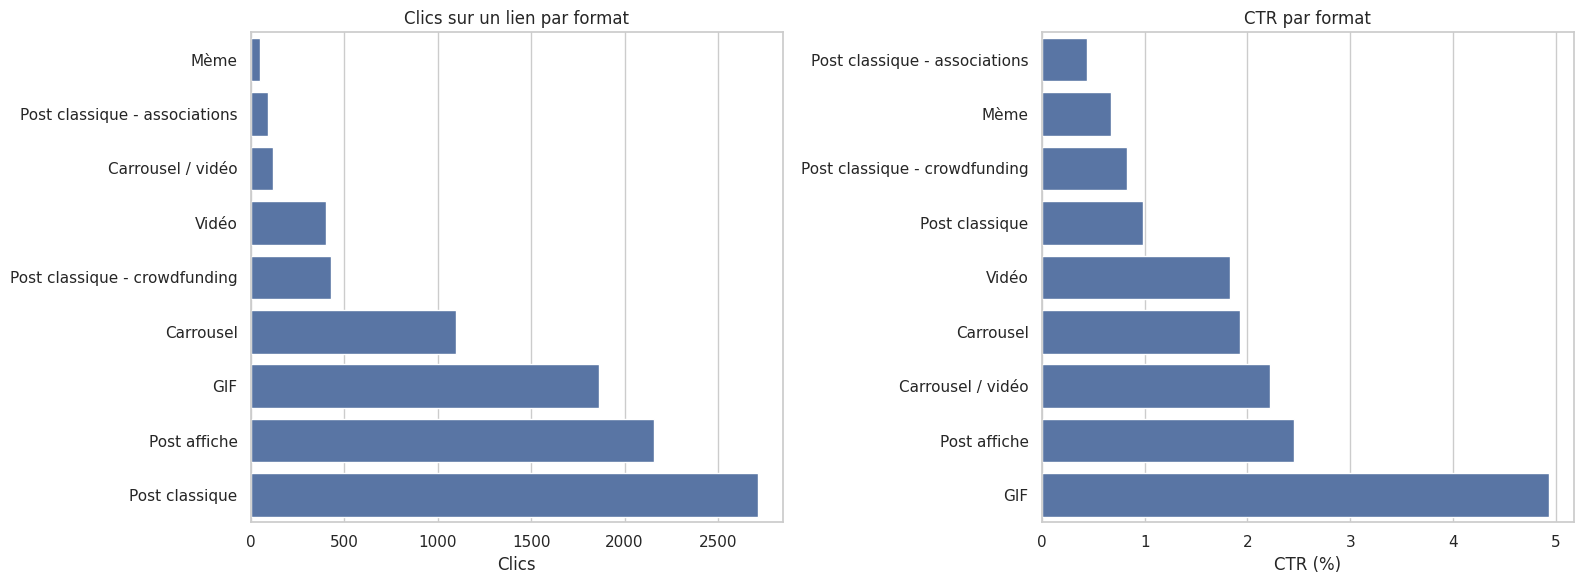

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_data = perf_format[perf_format["format_normalise"] != "Non renseigné"].copy()

sns.barplot(data=plot_data.sort_values("clics_lien"), y="format_normalise", x="clics_lien", ax=axes[0])
axes[0].set_title("Clics sur un lien par format")
axes[0].set_xlabel("Clics")
axes[0].set_ylabel("")

sns.barplot(data=plot_data.sort_values("ctr_pct"), y="format_normalise", x="ctr_pct", ax=axes[1])
axes[1].set_title("CTR par format")
axes[1].set_xlabel("CTR (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### 6.1 Publicités individuelles les plus attractives

In [11]:
perf_pub = aggregate_performance(df, "nom_de_la_publicite")
# Seuil minimal pour éviter de considérer comme championne une publicité très peu diffusée.
seuil_impressions = max(1000, perf_pub["impressions"].quantile(0.25))

top_volume = perf_pub.sort_values("clics_lien", ascending=False).head(15)
top_ctr = (perf_pub[perf_pub["impressions"] >= seuil_impressions]
           .sort_values("ctr_pct", ascending=False).head(15))

print("Top 15 en volume de clics")
display(top_volume.round(2))
print(f"Top 15 en CTR, avec au moins {seuil_impressions:,.0f} impressions")
display(top_ctr.round(2))

Top 15 en volume de clics


,nom_de_la_publicite,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
16,Promotion du site webÂ : https://missionme.app/crowdfunding/,45,115.99,49687,46498.0,2204.0,15603.0,0,4.44,0.05,31.40
17,Promotion du site webÂ : https://missionme.app/inscription-nl-crowdfunding/,35,71.68,15746,14532.0,1128.0,8352.0,0,7.16,0.06,53.04
14,Promotion du site webÂ : https://bit.ly/Ulule_MissionMe,47,151.66,39995,32367.0,577.0,5362.0,0,1.44,0.26,13.41
0,Campagne de trafic crowdfunding Publicité,3,69.99,50480,35040.0,443.0,445.0,0,0.88,0.16,0.88
101,"PublicationÂ : Â«Â ðŸ’¬ MissionMe, c'est pas un forum où tu passes des...Â Â»",7,11.81,4452,4362.0,415.0,1335.0,0,9.32,0.03,29.99
72,PublicationÂ : Â«Â Une start-up franÃ§aise invente le premier moyen...Â Â»,8,13.93,5368,4984.0,413.0,425.0,0,7.69,0.03,7.92
83,PublicationÂ : Â«Â ðŸ§° Galère mécanique ? Une panne qui gÃ¢che la route ?Â Â»,8,13.92,5334,5086.0,400.0,3938.0,0,7.50,0.03,73.83
87,PublicationÂ : Â«Â ðŸšðŸ’¨ PrÃªt pour ton road trip ou ta van-life ?Â Â»,6,11.94,3331,3119.0,287.0,2413.0,0,8.62,0.04,72.44
28,Publication InstagramÂ : Tu connais ce moment où...,14,23.68,8783,8636.0,270.0,2972.0,26,3.07,0.09,33.84
70,PublicationÂ : Â«Â Tu connais ce moment où tu cherches une infoâ€¦ et...Â Â»,7,11.97,4479,4315.0,260.0,1041.0,0,5.80,0.05,23.24


Top 15 en CTR, avec au moins 2,315 impressions


,nom_de_la_publicite,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
101,"PublicationÂ : Â«Â ðŸ’¬ MissionMe, c'est pas un forum où tu passes des...Â Â»",7,11.81,4452,4362.0,415.0,1335.0,0,9.32,0.03,29.99
87,PublicationÂ : Â«Â ðŸšðŸ’¨ PrÃªt pour ton road trip ou ta van-life ?Â Â»,6,11.94,3331,3119.0,287.0,2413.0,0,8.62,0.04,72.44
72,PublicationÂ : Â«Â Une start-up franÃ§aise invente le premier moyen...Â Â»,8,13.93,5368,4984.0,413.0,425.0,0,7.69,0.03,7.92
83,PublicationÂ : Â«Â ðŸ§° Galère mécanique ? Une panne qui gÃ¢che la route ?Â Â»,8,13.92,5334,5086.0,400.0,3938.0,0,7.50,0.03,73.83
39,Publication InstagramÂ : ðŸšðŸ’¨ PrÃªt pour ton road...,6,11.95,2691,2594.0,194.0,1825.0,0,7.21,0.06,67.82
17,Promotion du site webÂ : https://missionme.app/inscription-nl-crowdfunding/,35,71.68,15746,14532.0,1128.0,8352.0,0,7.16,0.06,53.04
70,PublicationÂ : Â«Â Tu connais ce moment où tu cherches une infoâ€¦ et...Â Â»,7,11.97,4479,4315.0,260.0,1041.0,0,5.80,0.05,23.24
61,"PublicationÂ : Â«Â Quand ton chat disparait, c'est le drame :Â Â»",7,11.93,3894,3529.0,192.0,1555.0,0,4.93,0.06,39.93
89,"PublicationÂ : Â«Â ðŸš€ Chez MissionMe, on adore relever les défis !Â Â»",7,11.86,5183,4934.0,243.0,297.0,0,4.69,0.05,5.73
16,Promotion du site webÂ : https://missionme.app/crowdfunding/,45,115.99,49687,46498.0,2204.0,15603.0,0,4.44,0.05,31.40


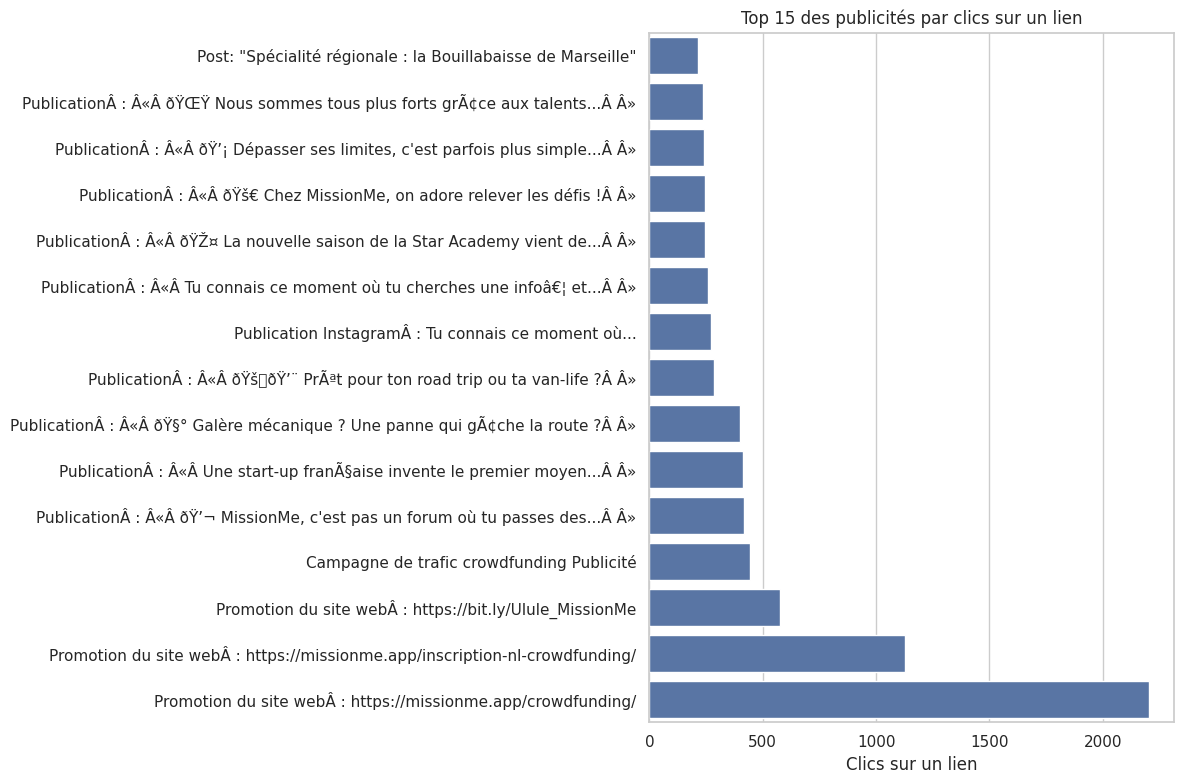

In [12]:
plt.figure(figsize=(12, 8))
sns.barplot(data=top_volume.sort_values("clics_lien"), y="nom_de_la_publicite", x="clics_lien")
plt.title("Top 15 des publicités par clics sur un lien")
plt.xlabel("Clics sur un lien")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Pourquoi sont-ils venus ? Analyse des motivations

Le fichier ne contient pas une question posée aux visiteurs. La motivation est donc **inférée à partir du thème du post**. Pour rendre l'analyse lisible, les thèmes détaillés sont regroupés en grandes familles de motivations.

In [13]:
def motivation_from_theme(theme):
    x = unidecode(str(theme)).lower()
    rules = [
        ("Crowdfunding / soutien au projet", ["crowdfunding", "ulule", "financement", "contributeur", "collectif", "cause"]),
        ("Entraide / solidarité", ["entraide", "solidarit", "aide", "micro-action", "partage", "lien humain", "vivre-ensemble"]),
        ("Information locale / pratique", ["info", "geolocal", "local", "imprevu", "copilote", "anti-panique", "tracas", "galere"]),
        ("Voyage / culture / découverte", ["voyage", "culture", "frontiere", "specialite", "regionale", "fromage", "espagn", "teleportation"]),
        ("Développement personnel / inspiration", ["inspir", "limite", "blocage", "heureux", "developpement personnel", "mystique", "medium"]),
        ("Inclusion / accessibilité", ["inclusion", "pmr", "handicap", "accessible"]),
        ("Écologie / consommation responsable", ["ecolog", "ecorespons", "environnement"]),
        ("Animaux", ["chat", "chien", "animal"]),
        ("Famille / éducation", ["parent", "rentrée", "scolaire", "grand", "adolesc"]),
        ("Divertissement / actualité", ["actu", "fete", "journee", "marronnier"]),
    ]
    if x == "non renseigne":
        return "Non renseigné"
    for label, keywords in rules:
        if any(k in x for k in keywords):
            return label
    return "Autres motivations"


df["motivation"] = df["theme_du_post"].apply(motivation_from_theme)
perf_motivation = aggregate_performance(df, "motivation").sort_values("clics_lien", ascending=False)
display(perf_motivation.round(2))

,motivation,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
6,Non renseigné,169,1953.59,238599,187418.0,4854.0,32836.0,548,2.03,0.40,13.76
3,Entraide / solidarité,189,369.12,194130,161764.0,3074.0,15545.0,68,1.58,0.12,8.01
7,Voyage / culture / découverte,142,349.79,143362,117704.0,1746.0,8215.0,12,1.22,0.20,5.73
5,Information locale / pratique,76,133.29,38652,36710.0,1149.0,8548.0,27,2.97,0.12,22.12
0,Autres motivations,92,188.90,97192,68941.0,1133.0,4910.0,16,1.17,0.17,5.05
1,Crowdfunding / soutien au projet,55,143.76,49177,45992.0,1005.0,1492.0,0,2.04,0.14,3.03
2,Développement personnel / inspiration,48,83.22,23383,21967.0,342.0,3502.0,12,1.46,0.24,14.98
4,Famille / éducation,19,35.91,11654,11136.0,318.0,2216.0,1,2.73,0.11,19.01
8,Écologie / consommation responsable,21,35.71,8467,7890.0,157.0,216.0,8,1.85,0.23,2.55


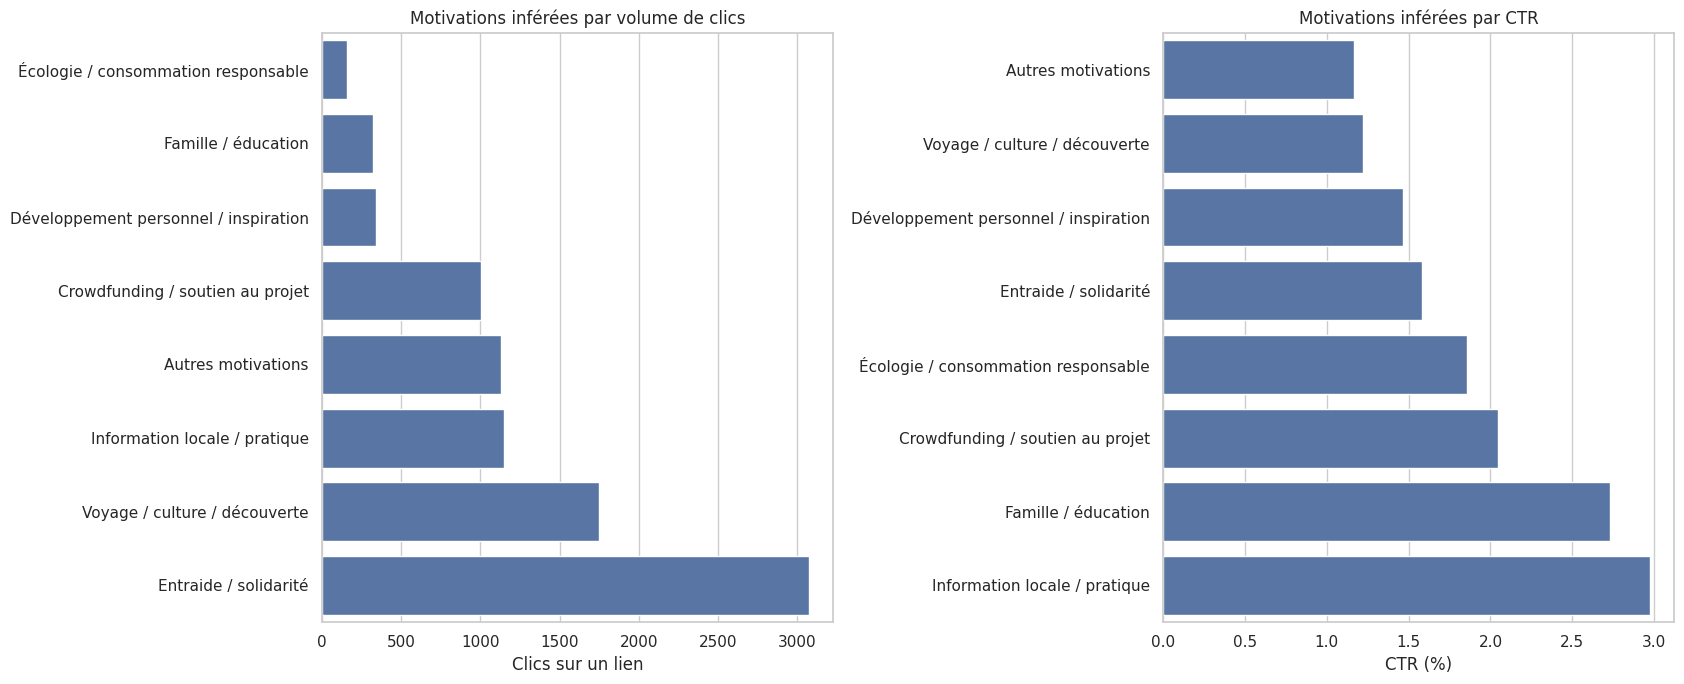

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
motiv = perf_motivation[perf_motivation["motivation"] != "Non renseigné"]

sns.barplot(data=motiv.sort_values("clics_lien"), y="motivation", x="clics_lien", ax=axes[0])
axes[0].set_title("Motivations inférées par volume de clics")
axes[0].set_xlabel("Clics sur un lien")
axes[0].set_ylabel("")

sns.barplot(data=motiv.sort_values("ctr_pct"), y="motivation", x="ctr_pct", ax=axes[1])
axes[1].set_title("Motivations inférées par CTR")
axes[1].set_xlabel("CTR (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### 7.1 Thèmes détaillés les plus performants

In [15]:
perf_theme = aggregate_performance(df, "theme_du_post")
perf_theme = perf_theme[perf_theme["theme_du_post"] != "Non renseigné"]

top_theme_volume = perf_theme.sort_values("clics_lien", ascending=False).head(20)
top_theme_ctr = (perf_theme[perf_theme["impressions"] >= 1000]
                 .sort_values("ctr_pct", ascending=False).head(20))

print("Thèmes générant le plus de clics")
display(top_theme_volume.round(2))
print("Thèmes ayant le meilleur CTR (minimum 1 000 impressions)")
display(top_theme_ctr.round(2))

Thèmes générant le plus de clics


,theme_du_post,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
44,Spécialités régionales,79,194.56,110049,86742.0,911.0,1675.0,7,0.83,0.21,1.52
45,Téléportation,17,35.86,14359,13713.0,601.0,618.0,1,4.19,0.06,4.30
32,MM = entraide,28,47.57,18510,17971.0,536.0,4453.0,26,2.90,0.09,24.06
55,gain de temps,7,11.81,4452,4362.0,415.0,1335.0,0,9.32,0.03,29.99
33,"MM = garant ""solidarité motarde""",8,13.92,5334,5086.0,400.0,3938.0,0,7.50,0.03,73.83
30,MM = copilote générateur d'infos fiables ou une solution aux imprévus,13,23.91,9666,9252.0,336.0,2880.0,0,3.48,0.07,29.80
38,MM = soutien / aide pour depasser ses limites / blocage,14,23.90,9110,8658.0,274.0,325.0,6,3.01,0.09,3.57
12,Citation inspirante : force du collectif,10,25.95,7468,7090.0,256.0,267.0,0,3.43,0.10,3.58
48,"actu ""buzz"" starAc / Starraclette MM = convivialité et partage / solution contre l’isolement.",7,29.86,43913,32605.0,245.0,246.0,0,0.56,0.12,0.56
37,MM = solutionneur de problème entraide locale ou à distance,7,11.86,5183,4934.0,243.0,297.0,0,4.69,0.05,5.73


Thèmes ayant le meilleur CTR (minimum 1 000 impressions)


,theme_du_post,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
55,gain de temps,7,11.81,4452,4362.0,415.0,1335.0,0,9.32,0.03,29.99
33,"MM = garant ""solidarité motarde""",8,13.92,5334,5086.0,400.0,3938.0,0,7.50,0.03,73.83
39,MissionMe = copilote,6,11.95,2691,2594.0,194.0,1825.0,0,7.21,0.06,67.82
37,MM = solutionneur de problème entraide locale ou à distance,7,11.86,5183,4934.0,243.0,297.0,0,4.69,0.05,5.73
58,la force du collectif,2,2.99,1292,1202.0,60.0,74.0,0,4.64,0.05,5.73
45,Téléportation,17,35.86,14359,13713.0,601.0,618.0,1,4.19,0.06,4.30
67,téléportation,2,9.77,2132,2015.0,86.0,90.0,0,4.03,0.11,4.22
52,chat MM = anti-panique,14,23.78,5921,5484.0,236.0,1616.0,14,3.99,0.10,27.29
5,Actu : 5 octobre_ Fête des Grands Pères,12,23.95,5174,4933.0,204.0,1200.0,1,3.94,0.12,23.19
22,La solidarité moderne et accessible,7,11.98,2821,2687.0,107.0,1209.0,0,3.79,0.11,42.86


## 8. Analyse des tranches d'âge ciblées

Les tranches sont extraites automatiquement de textes comme `18–35 ans`, `25 à 40 ans`, etc. Une même cible peut contenir plusieurs segments ; la tranche explicite est conservée lorsqu'elle existe.

In [16]:
def extract_age_range(text):
    if pd.isna(text) or str(text).lower() == "non renseigné":
        return "Non précisé"
    x = unidecode(str(text)).lower().replace("–", "-").replace("—", "-")
    match = re.search(r"(\d{2})\s*(?:-|a|à)\s*(\d{2})\s*ans", x)
    if match:
        low, high = map(int, match.groups())
        return f"{low}-{high} ans"
    # Mentions qualitatives, sans prétendre connaître l'âge réel.
    if "senior" in x or "retraite" in x:
        return "Seniors (âge non précisé)"
    if "jeune adulte" in x or "jeunes actifs" in x or "etudiant" in x:
        return "Jeunes adultes (âge non précisé)"
    if "adulte" in x:
        return "Adultes (âge non précisé)"
    return "Non précisé"


df["tranche_age_ciblee"] = df["cible_mm"].apply(extract_age_range)
perf_age = aggregate_performance(df, "tranche_age_ciblee").sort_values("clics_lien", ascending=False)
display(perf_age.round(2))

,tranche_age_ciblee,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
8,Non précisé,425,2512.41,514131,407707.0,8880.0,50851.0,597,1.73,0.28,9.89
7,Jeunes adultes (âge non précisé),178,333.60,135759,115906.0,2630.0,12477.0,70,1.94,0.13,9.19
9,Seniors (âge non précisé),49,94.47,29007,27187.0,701.0,3160.0,2,2.42,0.13,10.89
5,30-60 ans,30,61.65,19672,18546.0,554.0,730.0,5,2.82,0.11,3.71
2,20-40 ans,48,119.29,72132,58106.0,519.0,7820.0,4,0.72,0.23,10.84
3,25-40 ans,28,47.60,13774,12901.0,225.0,1121.0,8,1.63,0.21,8.14
1,20-35 ans,8,13.96,5592,5142.0,86.0,280.0,0,1.54,0.16,5.01
4,25-45 ans,21,35.61,7681,7511.0,74.0,450.0,4,0.96,0.48,5.86
0,18-35 ans,17,62.79,4000,3743.0,62.0,535.0,0,1.55,1.01,13.38
6,Adultes (âge non précisé),7,11.91,2868,2773.0,47.0,56.0,2,1.64,0.25,1.95


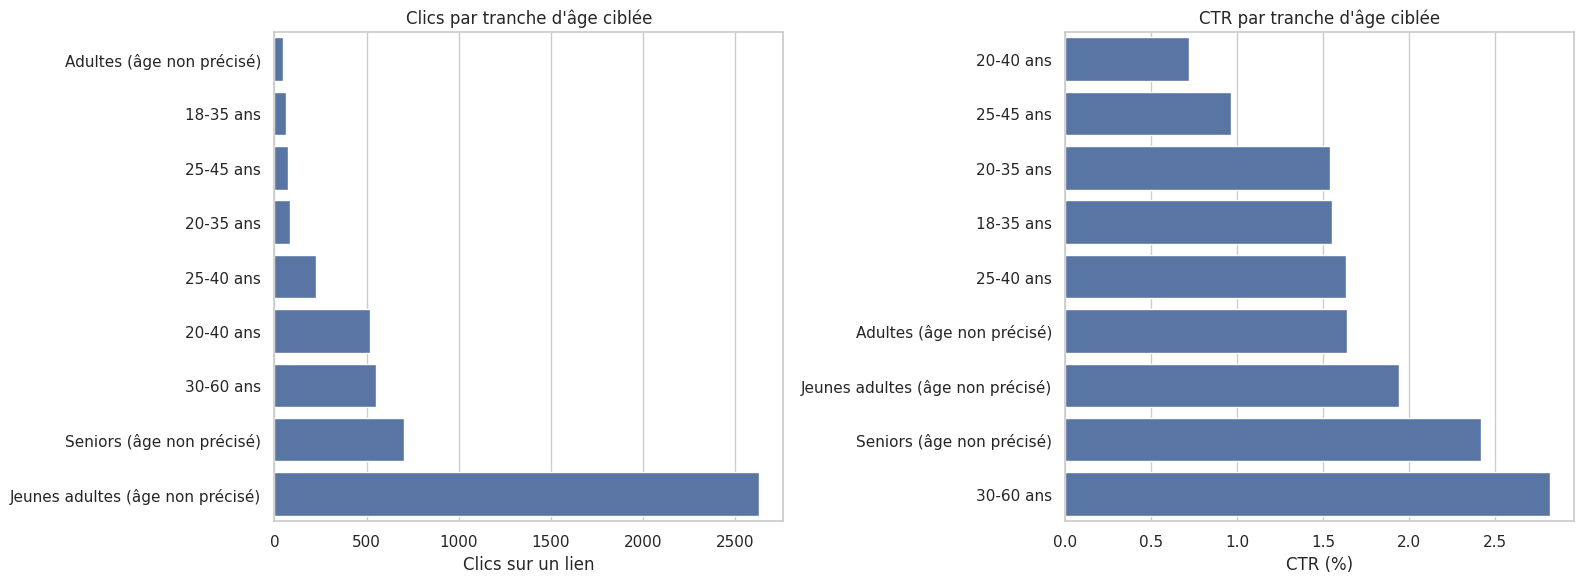

In [17]:
age_plot = perf_age[perf_age["tranche_age_ciblee"] != "Non précisé"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=age_plot.sort_values("clics_lien"), y="tranche_age_ciblee", x="clics_lien", ax=axes[0])
axes[0].set_title("Clics par tranche d'âge ciblée")
axes[0].set_xlabel("Clics sur un lien")
axes[0].set_ylabel("")

sns.barplot(data=age_plot.sort_values("ctr_pct"), y="tranche_age_ciblee", x="ctr_pct", ax=axes[1])
axes[1].set_title("CTR par tranche d'âge ciblée")
axes[1].set_xlabel("CTR (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 9. Effet du budget et de la diffusion

,montant_depense_eur,impressions,couverture,clics_sur_un_lien,interactions_avec_la_publication,followers_sur_instagram
montant_depense_eur,1.00,0.52,0.49,0.38,0.25,0.01
impressions,0.52,1.00,0.99,0.56,0.21,-0.20
couverture,0.49,0.99,1.00,0.56,0.20,-0.19
clics_sur_un_lien,0.38,0.56,0.56,1.00,0.49,-0.16
interactions_avec_la_publication,0.25,0.21,0.20,0.49,1.00,-0.32
followers_sur_instagram,0.01,-0.20,-0.19,-0.16,-0.32,1.00


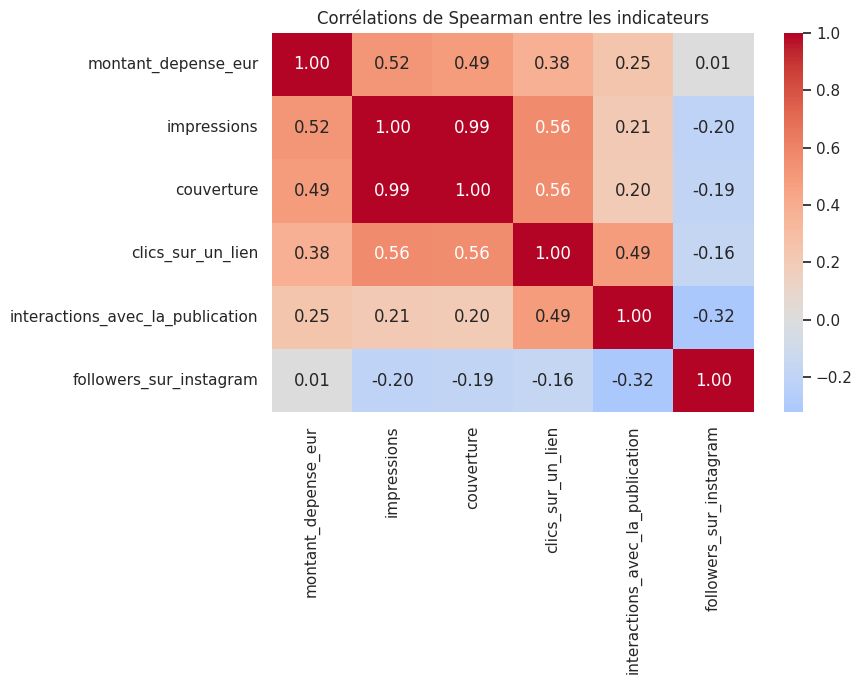

In [18]:
correlation_vars = ["montant_depense_eur", "impressions", "couverture", "clics_sur_un_lien",
                    "interactions_avec_la_publication", "followers_sur_instagram"]
corr = df[correlation_vars].corr(method="spearman")
display(corr.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations de Spearman entre les indicateurs")
plt.tight_layout()
plt.show()

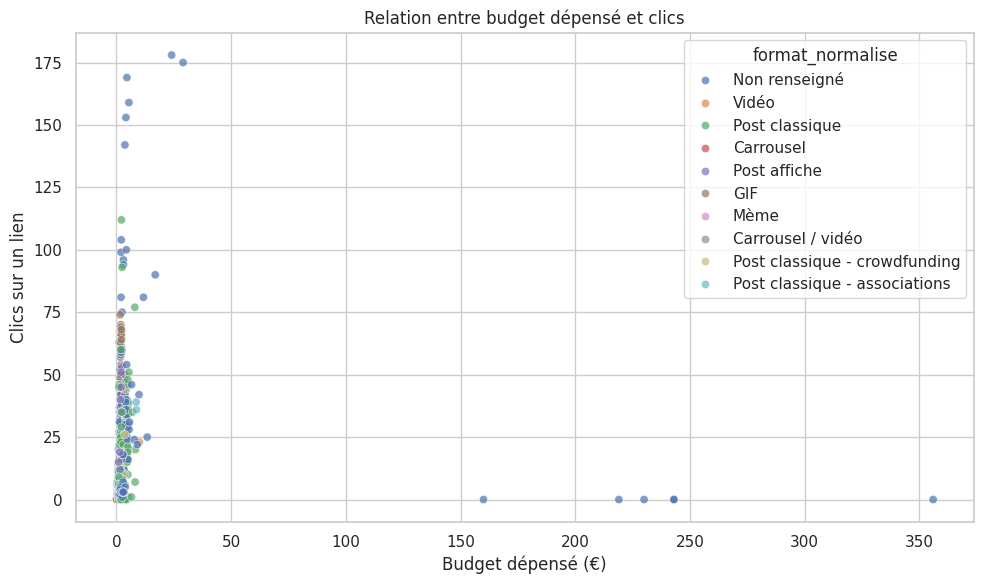

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="montant_depense_eur", y="clics_sur_un_lien", hue="format_normalise", alpha=0.7)
plt.title("Relation entre budget dépensé et clics")
plt.xlabel("Budget dépensé (€)")
plt.ylabel("Clics sur un lien")
plt.tight_layout()
plt.show()

## 10. Évolution temporelle

,mois,lignes,budget_eur,impressions,couverture,clics_lien,interactions,followers,ctr_pct,cpc_eur,taux_engagement_pct
0,2025-08,178,303.10,92709,88367.0,1630.0,14604.0,96,1.76,0.19,15.75
1,2025-09,179,308.03,110801,105203.0,3697.0,16567.0,25,3.34,0.08,14.95
2,2025-10,199,395.31,127131,109930.0,2868.0,22127.0,19,2.26,0.14,17.40
3,2025-11,234,797.54,461417,345928.0,5531.0,22577.0,15,1.20,0.14,4.89
4,2025-12,15,38.31,12132,10094.0,52.0,1605.0,0,0.43,0.74,13.23
5,NaT,6,1451.00,426,0.0,0.0,0.0,537,0.00,NaN,0.00


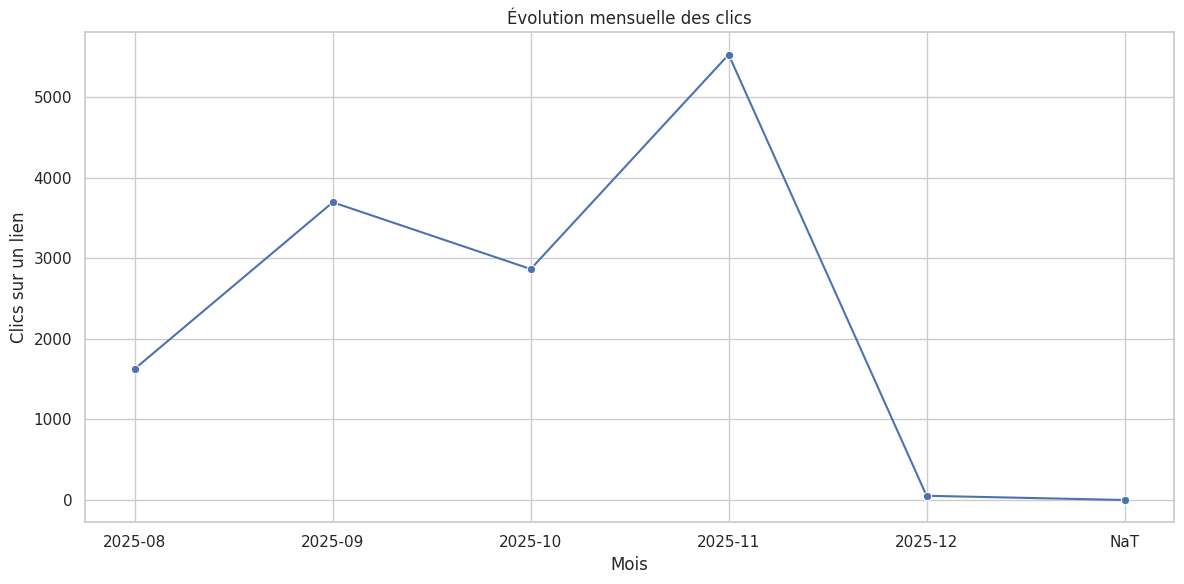

In [20]:
df["mois"] = df["fin"].dt.to_period("M").astype(str)
perf_mois = aggregate_performance(df, "mois").sort_values("mois")
display(perf_mois.round(2))

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=perf_mois, x="mois", y="clics_lien", marker="o", ax=ax1)
ax1.set_title("Évolution mensuelle des clics")
ax1.set_xlabel("Mois")
ax1.set_ylabel("Clics sur un lien")
plt.tight_layout()
plt.show()

## 11. Synthèse automatique des réponses métier

In [21]:
def first_valid(table, category_col, excluded=("Non renseigné", "Non précisé")):
    valid = table[~table[category_col].isin(excluded)].copy()
    return valid.iloc[0] if not valid.empty else None

best_format_volume = first_valid(perf_format.sort_values("clics_lien", ascending=False), "format_normalise")
best_format_ctr = first_valid(perf_format[perf_format["impressions"] >= 1000].sort_values("ctr_pct", ascending=False), "format_normalise")
best_motiv_volume = first_valid(perf_motivation.sort_values("clics_lien", ascending=False), "motivation")
best_motiv_ctr = first_valid(perf_motivation[perf_motivation["impressions"] >= 1000].sort_values("ctr_pct", ascending=False), "motivation")
best_age_volume = first_valid(perf_age.sort_values("clics_lien", ascending=False), "tranche_age_ciblee")
best_age_ctr = first_valid(perf_age[perf_age["impressions"] >= 1000].sort_values("ctr_pct", ascending=False), "tranche_age_ciblee")

print("RÉPONSE 1 — Qu'est-ce qui a attiré le plus ?")
print(f"• En volume : {best_format_volume['format_normalise']} — {best_format_volume['clics_lien']:,.0f} clics.")
print(f"• En efficacité : {best_format_ctr['format_normalise']} — CTR {best_format_ctr['ctr_pct']:.2f} % et CPC {best_format_ctr['cpc_eur']:.2f} €.")

print("\nRÉPONSE 2 — Pourquoi sont-ils venus ?")
print(f"• Motivation dominante en volume : {best_motiv_volume['motivation']} — {best_motiv_volume['clics_lien']:,.0f} clics.")
print(f"• Motivation la plus efficace : {best_motiv_ctr['motivation']} — CTR {best_motiv_ctr['ctr_pct']:.2f} %.")
print("• Cette motivation est inférée à partir du contenu des posts, et non déclarée directement par les visiteurs.")

print("\nRÉPONSE 3 — Quelle tranche d'âge ?")
print(f"• Tranche ciblée dominante en volume : {best_age_volume['tranche_age_ciblee']} — {best_age_volume['clics_lien']:,.0f} clics.")
print(f"• Tranche ciblée la plus efficace : {best_age_ctr['tranche_age_ciblee']} — CTR {best_age_ctr['ctr_pct']:.2f} %.")
print("• Il s'agit du ciblage des campagnes, pas de l'âge observé des visiteurs.")

RÉPONSE 1 — Qu'est-ce qui a attiré le plus ?
• En volume : Post classique — 2,712 clics.
• En efficacité : GIF — CTR 4.93 % et CPC 0.06 €.

RÉPONSE 2 — Pourquoi sont-ils venus ?
• Motivation dominante en volume : Entraide / solidarité — 3,074 clics.
• Motivation la plus efficace : Information locale / pratique — CTR 2.97 %.
• Cette motivation est inférée à partir du contenu des posts, et non déclarée directement par les visiteurs.

RÉPONSE 3 — Quelle tranche d'âge ?
• Tranche ciblée dominante en volume : Jeunes adultes (âge non précisé) — 2,630 clics.
• Tranche ciblée la plus efficace : 30-60 ans — CTR 2.82 %.
• Il s'agit du ciblage des campagnes, pas de l'âge observé des visiteurs.


## 12. Recommandations marketing

Les recommandations doivent combiner :
- le volume de clics ;
- le CTR ;
- le CPC ;
- un volume minimal d'impressions ;
- la cohérence avec les objectifs de MissionMe.

Éviter de réallouer le budget uniquement sur la base d'un CTR élevé obtenu avec très peu d'impressions. Tester les meilleurs couples **format × motivation × cible** avec des budgets comparables permettrait une conclusion plus causale.

In [22]:
# Tableau croisé format × motivation pour identifier les combinaisons prometteuses.
combo = (df.groupby(["format_normalise", "motivation"])
         .agg(budget_eur=("montant_depense_eur", "sum"),
              impressions=("impressions", "sum"),
              clics_lien=("clics_sur_un_lien", "sum"),
              interactions=("interactions_avec_la_publication", "sum"))
         .reset_index())
combo["ctr_pct"] = safe_divide(combo["clics_lien"], combo["impressions"], 100)
combo["cpc_eur"] = safe_divide(combo["budget_eur"], combo["clics_lien"])

combo_reliable = combo[(combo["impressions"] >= 1000) & (combo["format_normalise"] != "Non renseigné")]
display(combo_reliable.sort_values(["ctr_pct", "clics_lien"], ascending=[False, False]).head(20).round(2))

,format_normalise,motivation,budget_eur,impressions,clics_lien,interactions,ctr_pct,cpc_eur
9,GIF,Information locale / pratique,23.89,6022,481.0,4238.0,7.99,0.05
7,GIF,Autres motivations,35.51,7970,448.0,2261.0,5.62,0.08
8,GIF,Entraide / solidarité,61.49,23844,936.0,8391.0,3.93,0.07
1,Carrousel,Entraide / solidarité,11.98,2821,107.0,1209.0,3.79,0.11
6,Carrousel / vidéo,Entraide / solidarité,11.96,3306,94.0,1331.0,2.84,0.13
2,Carrousel,Famille / éducation,35.91,11654,318.0,2216.0,2.73,0.11
13,Post affiche,Crowdfunding / soutien au projet,73.06,25349,687.0,857.0,2.71,0.11
15,Post affiche,Entraide / solidarité,118.96,41273,1115.0,2970.0,2.70,0.11
3,Carrousel,Information locale / pratique,73.59,20373,459.0,2899.0,2.25,0.16
26,Vidéo,Autres motivations,33.91,7142,156.0,1886.0,2.18,0.22


## 13. Export des résultats

In [23]:
output_file = "resultats_analyse_missionme.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="donnees_preparees", index=False)
    perf_format.to_excel(writer, sheet_name="performance_formats", index=False)
    perf_theme.to_excel(writer, sheet_name="performance_themes", index=False)
    perf_motivation.to_excel(writer, sheet_name="motivations", index=False)
    perf_age.to_excel(writer, sheet_name="tranches_age_ciblees", index=False)
    perf_pub.to_excel(writer, sheet_name="publicites", index=False)
    perf_mois.to_excel(writer, sheet_name="performance_mensuelle", index=False)
    combo.to_excel(writer, sheet_name="format_motivation", index=False)

print(f"Fichier généré : {output_file}")
files.download(output_file)

Fichier généré : resultats_analyse_missionme.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion méthodologique

- Le **clic sur un lien** est retenu comme principal signal d'attraction active.
- Les impressions mesurent l'exposition, pas l'intérêt.
- Les motivations sont inférées à partir des thèmes des posts.
- Les âges analysés sont les **âges ciblés par les campagnes**, pas les âges réels des visiteurs.
- Pour répondre avec certitude à « qui est réellement venu ? », il faudrait exporter depuis Meta Ads Manager une ventilation démographique des clics, visites de page de destination ou conversions par âge et sexe.